Device: cpu
Epoch 1/10 | Train Loss: 0.6088 | Train Acc: 0.6614 | Val Loss: 0.5262 | Val Acc: 0.7502
Epoch 2/10 | Train Loss: 0.4858 | Train Acc: 0.7732 | Val Loss: 0.4499 | Val Acc: 0.8018
Epoch 3/10 | Train Loss: 0.4921 | Train Acc: 0.7591 | Val Loss: 0.4693 | Val Acc: 0.7996
Epoch 4/10 | Train Loss: 0.3892 | Train Acc: 0.8314 | Val Loss: 0.4166 | Val Acc: 0.8206
Epoch 5/10 | Train Loss: 0.3166 | Train Acc: 0.8712 | Val Loss: 0.3963 | Val Acc: 0.8316
Epoch 6/10 | Train Loss: 0.2698 | Train Acc: 0.8931 | Val Loss: 0.3997 | Val Acc: 0.8302
Epoch 7/10 | Train Loss: 0.2413 | Train Acc: 0.9041 | Val Loss: 0.3628 | Val Acc: 0.8444
Epoch 8/10 | Train Loss: 0.2006 | Train Acc: 0.9239 | Val Loss: 0.3875 | Val Acc: 0.8526
Epoch 9/10 | Train Loss: 0.1623 | Train Acc: 0.9375 | Val Loss: 0.3858 | Val Acc: 0.8616
Epoch 10/10 | Train Loss: 0.1489 | Train Acc: 0.9448 | Val Loss: 0.3944 | Val Acc: 0.8554

TEST ACCURACY: 0.85616

Saved to results/lstm_results.pkl


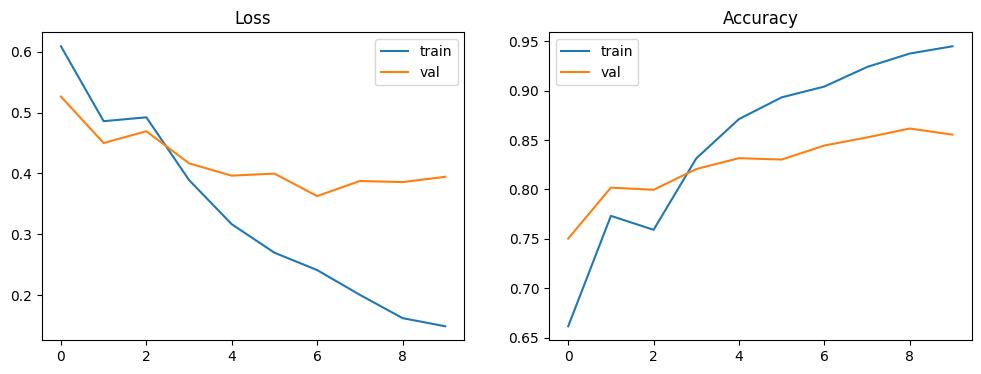


Training time: 455.2036554813385


In [3]:
import os
import time
import pickle

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import accuracy_score

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences


MODEL_NAME = "LSTM"

VOCAB_SIZE = 10000
MAX_LEN = 200

EMBED_SIZE = 128
HIDDEN_SIZE = 128

BATCH_SIZE = 64
EPOCHS = 10
LR = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

x_train = pad_sequences(x_train, maxlen=MAX_LEN)
x_test = pad_sequences(x_test, maxlen=MAX_LEN)

x_train = torch.LongTensor(x_train)
y_train = torch.FloatTensor(y_train)

x_test = torch.LongTensor(x_test)
y_test = torch.FloatTensor(y_test)

dataset = TensorDataset(x_train, y_train)
test_dataset = TensorDataset(x_test, y_test)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)


class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_SIZE)

        self.lstm = nn.LSTM(
            input_size=EMBED_SIZE,
            hidden_size=HIDDEN_SIZE,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.5)

        self.fc = nn.Linear(HIDDEN_SIZE, 1)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)

        _, (hidden, _) = self.lstm(x)

        hidden = hidden[-1]
        hidden = self.dropout(hidden)

        out = self.fc(hidden)
        out = self.sigmoid(out)

        return out.squeeze()

model = LSTMModel().to(device)

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0


start_time = time.time()

for epoch in range(EPOCHS):

    model.train()

    train_loss = 0
    train_preds, train_labels = [], []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        out = model(x)
        loss = criterion(out, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = (out >= 0.5).float()

        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(y.cpu().numpy())

    train_acc = accuracy_score(train_labels, train_preds)

    model.eval()

    val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            out = model(x)
            loss = criterion(out, y)

            val_loss += loss.item()

            preds = (out >= 0.5).float()

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y.cpu().numpy())

    val_acc = accuracy_score(val_labels, val_preds)

    train_losses.append(train_loss / len(train_loader))
    val_losses.append(val_loss / len(val_loader))

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = model.state_dict()

training_time = time.time() - start_time

model.load_state_dict(best_state)

model.eval()

test_labels, test_preds, test_probs = [], [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)

        out = model(x)

        probs = out.cpu().numpy()
        preds = (out >= 0.5).float().cpu().numpy()

        test_probs.extend(probs)
        test_preds.extend(preds)
        test_labels.extend(y.numpy())

test_acc = accuracy_score(test_labels, test_preds)

print("\nTEST ACCURACY:", test_acc)


os.makedirs("results", exist_ok=True)

results = {
    "model_name": MODEL_NAME,

    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_accuracies": train_accs,
    "val_accuracies": val_accs,

    "test_labels": test_labels,
    "test_predictions": test_preds,
    "test_probabilities": test_probs,

    "training_time": training_time
}

with open("results/lstm_results.pkl", "wb") as f:
    pickle.dump(results, f)

print("\nSaved to results/lstm_results.pkl")


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="train")
plt.plot(val_accs, label="val")
plt.title("Accuracy")
plt.legend()

plt.show()

print("\nTraining time:", training_time)